0단계

▶ [Stage 0] 리뷰 0개 (완전 침묵) 게임 태그 분석 준비 중...


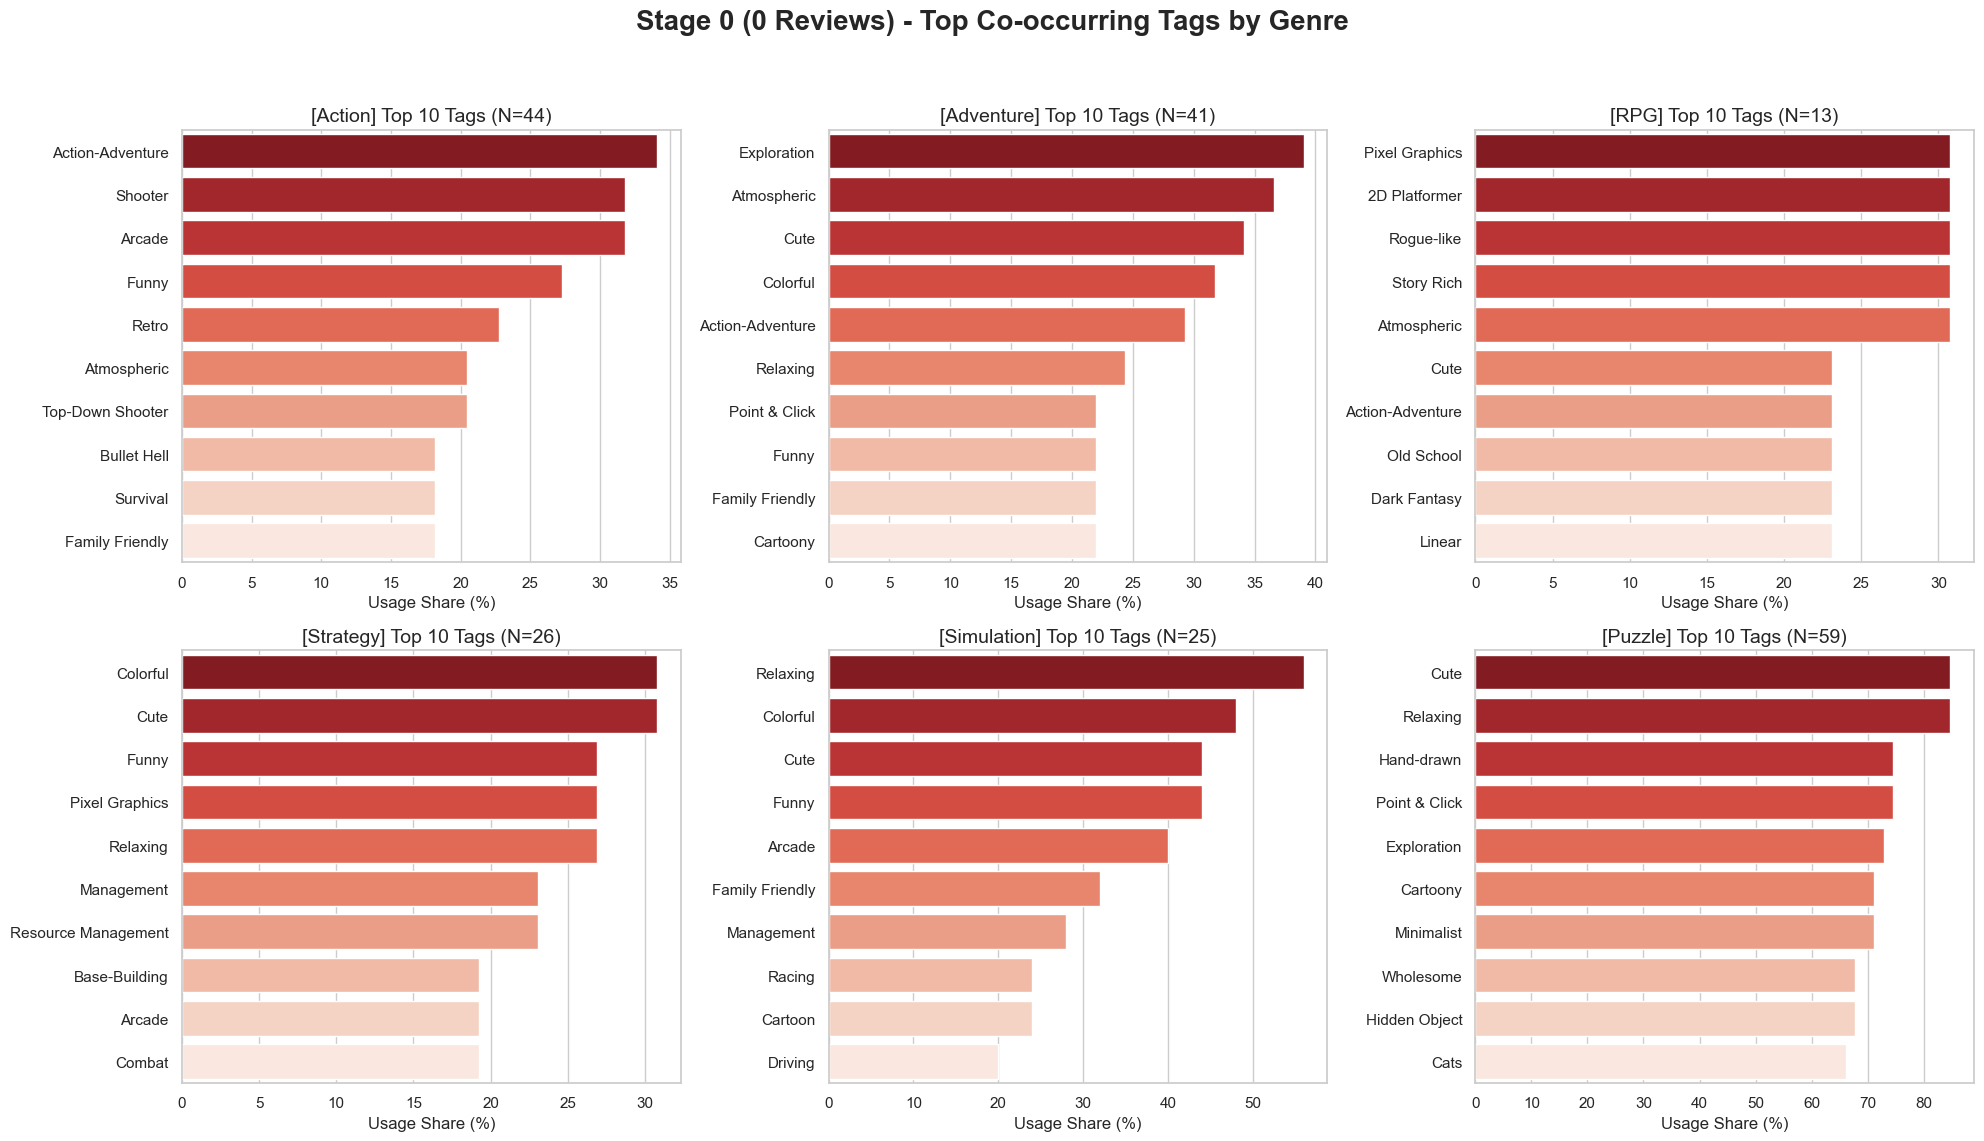


💡 [Stage 0] 장르별 핵심 동반 태그 TOP 10 요약


,Action,Adventure,RPG,Strategy,Simulation,Puzzle
Top 1,Action-Adventure,Exploration,Pixel Graphics,Colorful,Relaxing,Cute
Top 2,Shooter,Atmospheric,2D Platformer,Cute,Colorful,Relaxing
Top 3,Arcade,Cute,Rogue-like,Funny,Cute,Hand-drawn
Top 4,Funny,Colorful,Story Rich,Pixel Graphics,Funny,Point & Click
Top 5,Retro,Action-Adventure,Atmospheric,Relaxing,Arcade,Exploration
Top 6,Atmospheric,Relaxing,Cute,Management,Family Friendly,Cartoony
Top 7,Top-Down Shooter,Point & Click,Action-Adventure,Resource Management,Management,Minimalist
Top 8,Bullet Hell,Funny,Old School,Base-Building,Racing,Wholesome
Top 9,Survival,Family Friendly,Dark Fantasy,Arcade,Cartoon,Hidden Object
Top 10,Family Friendly,Cartoony,Linear,Combat,Driving,Cats


In [1]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("="*60)
print("▶ [Stage 0] 리뷰 0개 (완전 침묵) 게임 태그 분석 준비 중...")
print("="*60)

# 1. 데이터 로드
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv'
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_all = pd.concat([df_silence, df_graded], ignore_index=True)
df_all.drop_duplicates(subset=['appid'], inplace=True)

# 2. Stage 0 필터링 (리뷰 0개)
df_target = df_all[df_all['total_reviews'] == 0].copy()

# 3. 태그 추출 함수
def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_target['tag_list'] = df_target['tags'].apply(extract_tags)

# 4. 분석 설정
target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Puzzle']
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access'] + target_genres

genre_top_tags = {}
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
fig.suptitle("Stage 0 (0 Reviews) - Top Co-occurring Tags by Genre", fontsize=20, fontweight='bold')

for i, genre in enumerate(target_genres):
    genre_df = df_target[df_target['tag_list'].apply(lambda x: genre in x)]
    total_genre_games = len(genre_df)
    
    if total_genre_games == 0:
        continue
        
    all_tags_in_genre = []
    for tags in genre_df['tag_list']:
        filtered_tags = [t for t in tags if t not in common_tags]
        all_tags_in_genre.extend(filtered_tags)
        
    tag_counts = Counter(all_tags_in_genre)
    top10_tags = pd.Series({tag: (count / total_genre_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
    genre_top_tags[genre] = top10_tags
    
    plot_df = top10_tags.reset_index()
    plot_df.columns = ['Tag', 'Share(%)']
    
    sns.barplot(data=plot_df, x='Share(%)', y='Tag', ax=axes[i], palette='Reds_r')
    axes[i].set_title(f"[{genre}] Top 10 Tags (N={total_genre_games})", fontsize=14)
    axes[i].set_xlabel("Usage Share (%)")
    axes[i].set_ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n💡 [Stage 0] 장르별 핵심 동반 태그 TOP 10 요약")
summary_df = pd.DataFrame({genre: tags.index.tolist() for genre, tags in genre_top_tags.items()})
summary_df.index = [f"Top {i+1}" for i in range(10)]
display(summary_df)

1단계

▶ [Stage 1] 리뷰 1~9개 (정체 구간) 게임 태그 분석 준비 중...


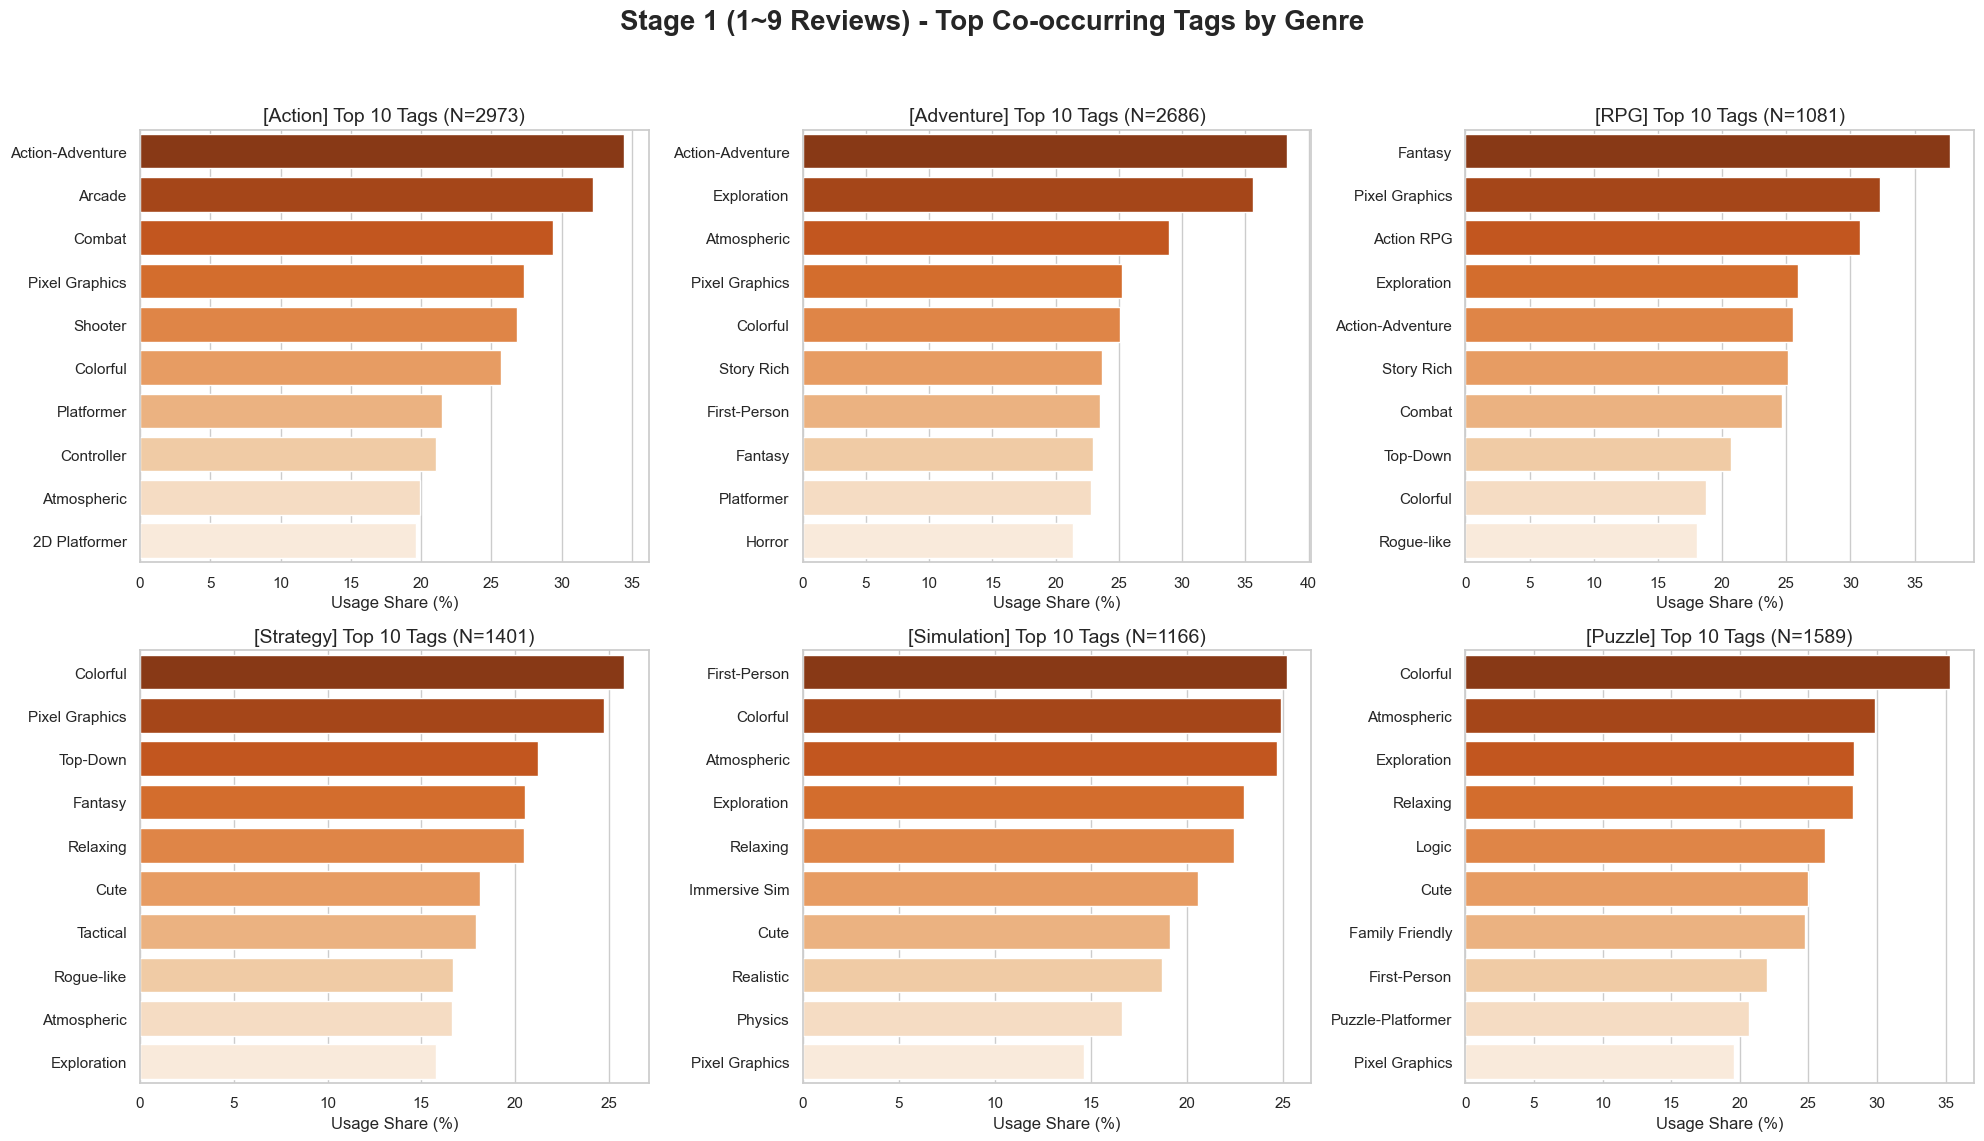


💡 [Stage 1] 장르별 핵심 동반 태그 TOP 10 요약


,Action,Adventure,RPG,Strategy,Simulation,Puzzle
Top 1,Action-Adventure,Action-Adventure,Fantasy,Colorful,First-Person,Colorful
Top 2,Arcade,Exploration,Pixel Graphics,Pixel Graphics,Colorful,Atmospheric
Top 3,Combat,Atmospheric,Action RPG,Top-Down,Atmospheric,Exploration
Top 4,Pixel Graphics,Pixel Graphics,Exploration,Fantasy,Exploration,Relaxing
Top 5,Shooter,Colorful,Action-Adventure,Relaxing,Relaxing,Logic
Top 6,Colorful,Story Rich,Story Rich,Cute,Immersive Sim,Cute
Top 7,Platformer,First-Person,Combat,Tactical,Cute,Family Friendly
Top 8,Controller,Fantasy,Top-Down,Rogue-like,Realistic,First-Person
Top 9,Atmospheric,Platformer,Colorful,Atmospheric,Physics,Puzzle-Platformer
Top 10,2D Platformer,Horror,Rogue-like,Exploration,Pixel Graphics,Pixel Graphics


In [2]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("="*60)
print("▶ [Stage 1] 리뷰 1~9개 (정체 구간) 게임 태그 분석 준비 중...")
print("="*60)

# 1. 데이터 로드
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv'
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_all = pd.concat([df_silence, df_graded], ignore_index=True)
df_all.drop_duplicates(subset=['appid'], inplace=True)

# 2. Stage 1 필터링 (리뷰 1~9개)
df_target = df_all[(df_all['total_reviews'] >= 1) & (df_all['total_reviews'] <= 9)].copy()

# 3. 태그 추출 함수
def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_target['tag_list'] = df_target['tags'].apply(extract_tags)

# 4. 분석 설정
target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Puzzle']
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access'] + target_genres

genre_top_tags = {}
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
fig.suptitle("Stage 1 (1~9 Reviews) - Top Co-occurring Tags by Genre", fontsize=20, fontweight='bold')

for i, genre in enumerate(target_genres):
    genre_df = df_target[df_target['tag_list'].apply(lambda x: genre in x)]
    total_genre_games = len(genre_df)
    
    if total_genre_games == 0:
        continue
        
    all_tags_in_genre = []
    for tags in genre_df['tag_list']:
        filtered_tags = [t for t in tags if t not in common_tags]
        all_tags_in_genre.extend(filtered_tags)
        
    tag_counts = Counter(all_tags_in_genre)
    top10_tags = pd.Series({tag: (count / total_genre_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
    genre_top_tags[genre] = top10_tags
    
    plot_df = top10_tags.reset_index()
    plot_df.columns = ['Tag', 'Share(%)']
    
    sns.barplot(data=plot_df, x='Share(%)', y='Tag', ax=axes[i], palette='Oranges_r')
    axes[i].set_title(f"[{genre}] Top 10 Tags (N={total_genre_games})", fontsize=14)
    axes[i].set_xlabel("Usage Share (%)")
    axes[i].set_ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n💡 [Stage 1] 장르별 핵심 동반 태그 TOP 10 요약")
summary_df = pd.DataFrame({genre: tags.index.tolist() for genre, tags in genre_top_tags.items()})
summary_df.index = [f"Top {i+1}" for i in range(10)]
display(summary_df)

▶ [Stage 2] 리뷰 10~49개 (초기 도약) 게임 태그 분석 준비 중...


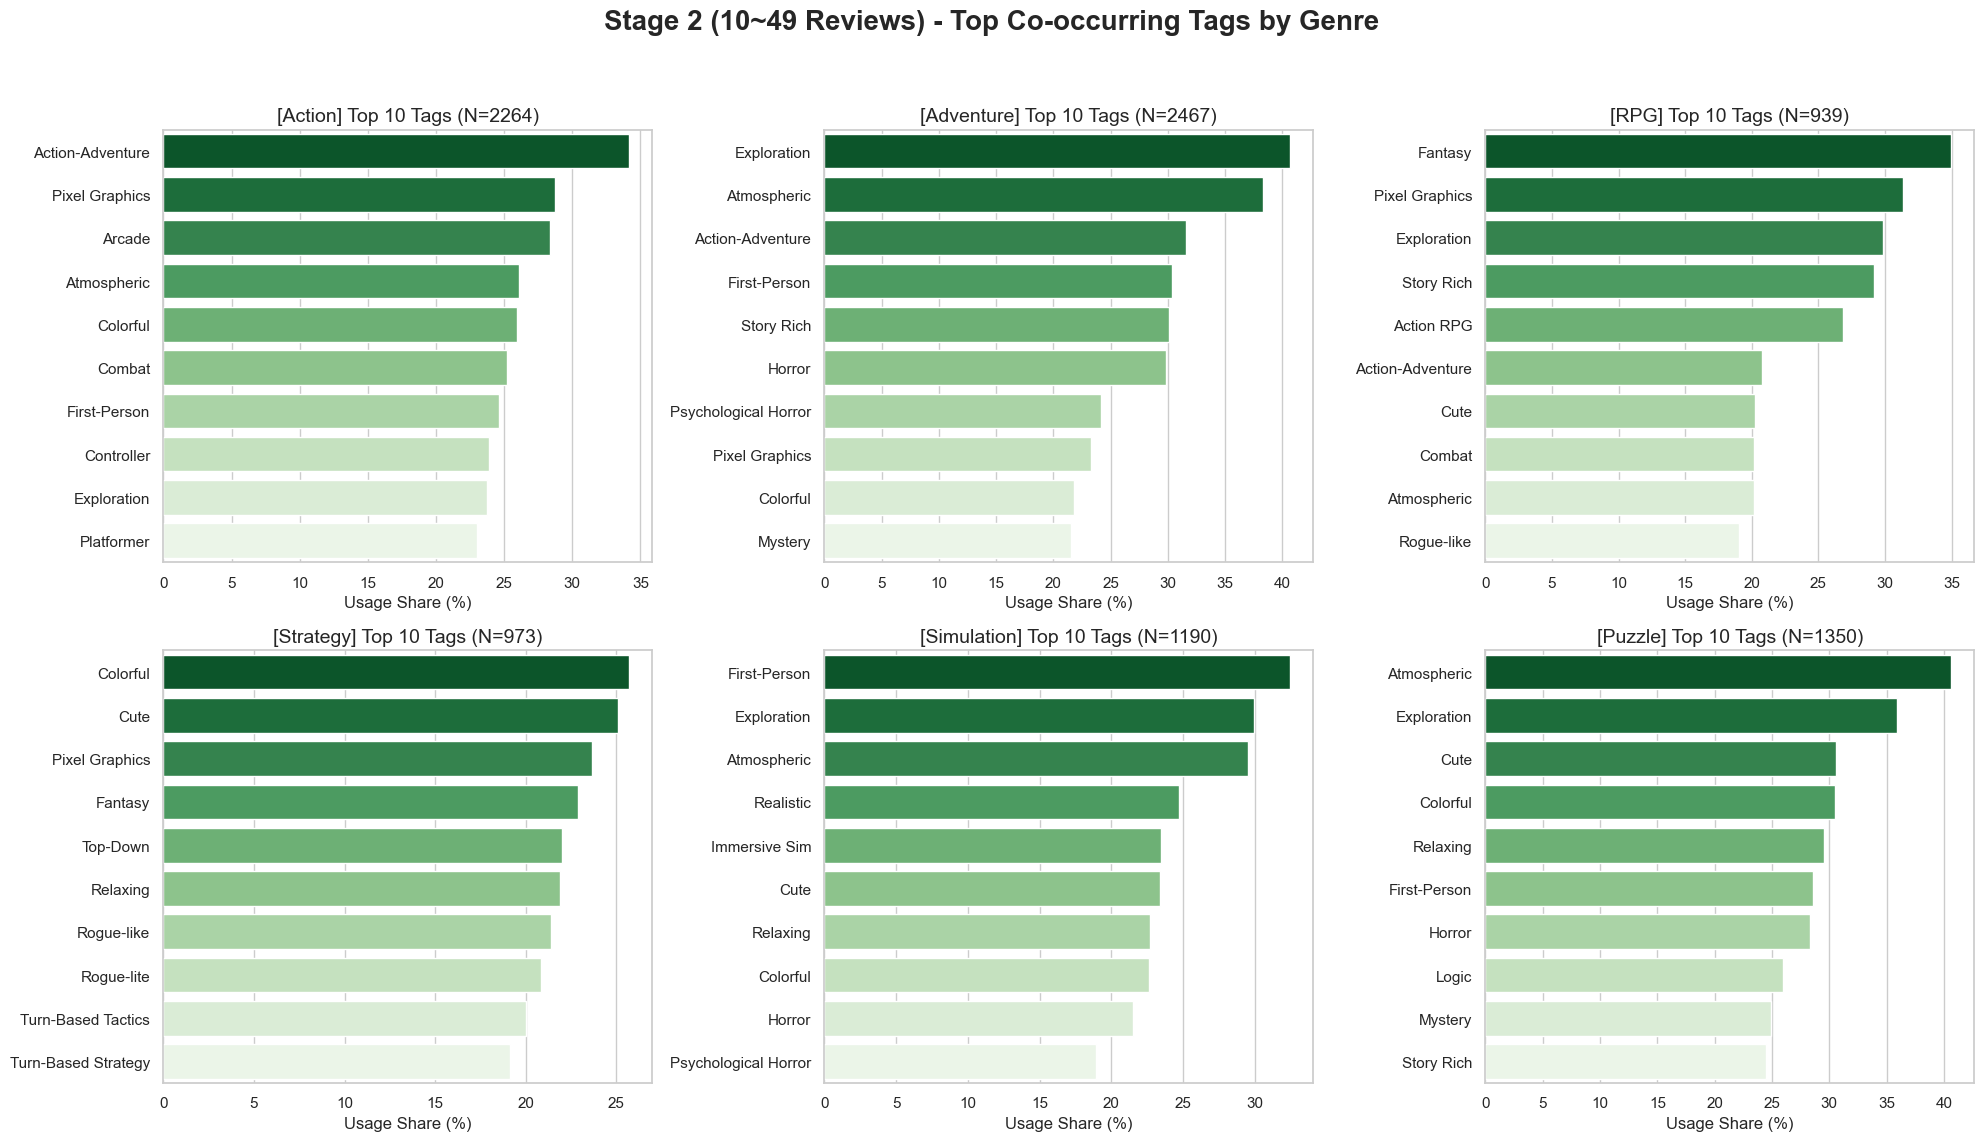


💡 [Stage 2] 장르별 핵심 동반 태그 TOP 10 요약


,Action,Adventure,RPG,Strategy,Simulation,Puzzle
Top 1,Action-Adventure,Exploration,Fantasy,Colorful,First-Person,Atmospheric
Top 2,Pixel Graphics,Atmospheric,Pixel Graphics,Cute,Exploration,Exploration
Top 3,Arcade,Action-Adventure,Exploration,Pixel Graphics,Atmospheric,Cute
Top 4,Atmospheric,First-Person,Story Rich,Fantasy,Realistic,Colorful
Top 5,Colorful,Story Rich,Action RPG,Top-Down,Immersive Sim,Relaxing
Top 6,Combat,Horror,Action-Adventure,Relaxing,Cute,First-Person
Top 7,First-Person,Psychological Horror,Cute,Rogue-like,Relaxing,Horror
Top 8,Controller,Pixel Graphics,Combat,Rogue-lite,Colorful,Logic
Top 9,Exploration,Colorful,Atmospheric,Turn-Based Tactics,Horror,Mystery
Top 10,Platformer,Mystery,Rogue-like,Turn-Based Strategy,Psychological Horror,Story Rich


In [3]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("="*60)
print("▶ [Stage 2] 리뷰 10~49개 (초기 도약) 게임 태그 분석 준비 중...")
print("="*60)

# 1. 데이터 로드
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv'
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_all = pd.concat([df_silence, df_graded], ignore_index=True)
df_all.drop_duplicates(subset=['appid'], inplace=True)

# 2. Stage 2 필터링 (리뷰 10~49개)
df_target = df_all[(df_all['total_reviews'] >= 10) & (df_all['total_reviews'] <= 49)].copy()

# 3. 태그 추출 함수
def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_target['tag_list'] = df_target['tags'].apply(extract_tags)

# 4. 분석 설정
target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Puzzle']
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access'] + target_genres

genre_top_tags = {}
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
fig.suptitle("Stage 2 (10~49 Reviews) - Top Co-occurring Tags by Genre", fontsize=20, fontweight='bold')

for i, genre in enumerate(target_genres):
    genre_df = df_target[df_target['tag_list'].apply(lambda x: genre in x)]
    total_genre_games = len(genre_df)
    
    if total_genre_games == 0:
        continue
        
    all_tags_in_genre = []
    for tags in genre_df['tag_list']:
        filtered_tags = [t for t in tags if t not in common_tags]
        all_tags_in_genre.extend(filtered_tags)
        
    tag_counts = Counter(all_tags_in_genre)
    top10_tags = pd.Series({tag: (count / total_genre_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
    genre_top_tags[genre] = top10_tags
    
    plot_df = top10_tags.reset_index()
    plot_df.columns = ['Tag', 'Share(%)']
    
    sns.barplot(data=plot_df, x='Share(%)', y='Tag', ax=axes[i], palette='Greens_r')
    axes[i].set_title(f"[{genre}] Top 10 Tags (N={total_genre_games})", fontsize=14)
    axes[i].set_xlabel("Usage Share (%)")
    axes[i].set_ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n💡 [Stage 2] 장르별 핵심 동반 태그 TOP 10 요약")
summary_df = pd.DataFrame({genre: tags.index.tolist() for genre, tags in genre_top_tags.items()})
summary_df.index = [f"Top {i+1}" for i in range(10)]
display(summary_df)

0+1단계

▶ [Stage 0+1] 리뷰 0~9개 (초기 정체 구간 통합) 게임 태그 분석 준비 중...


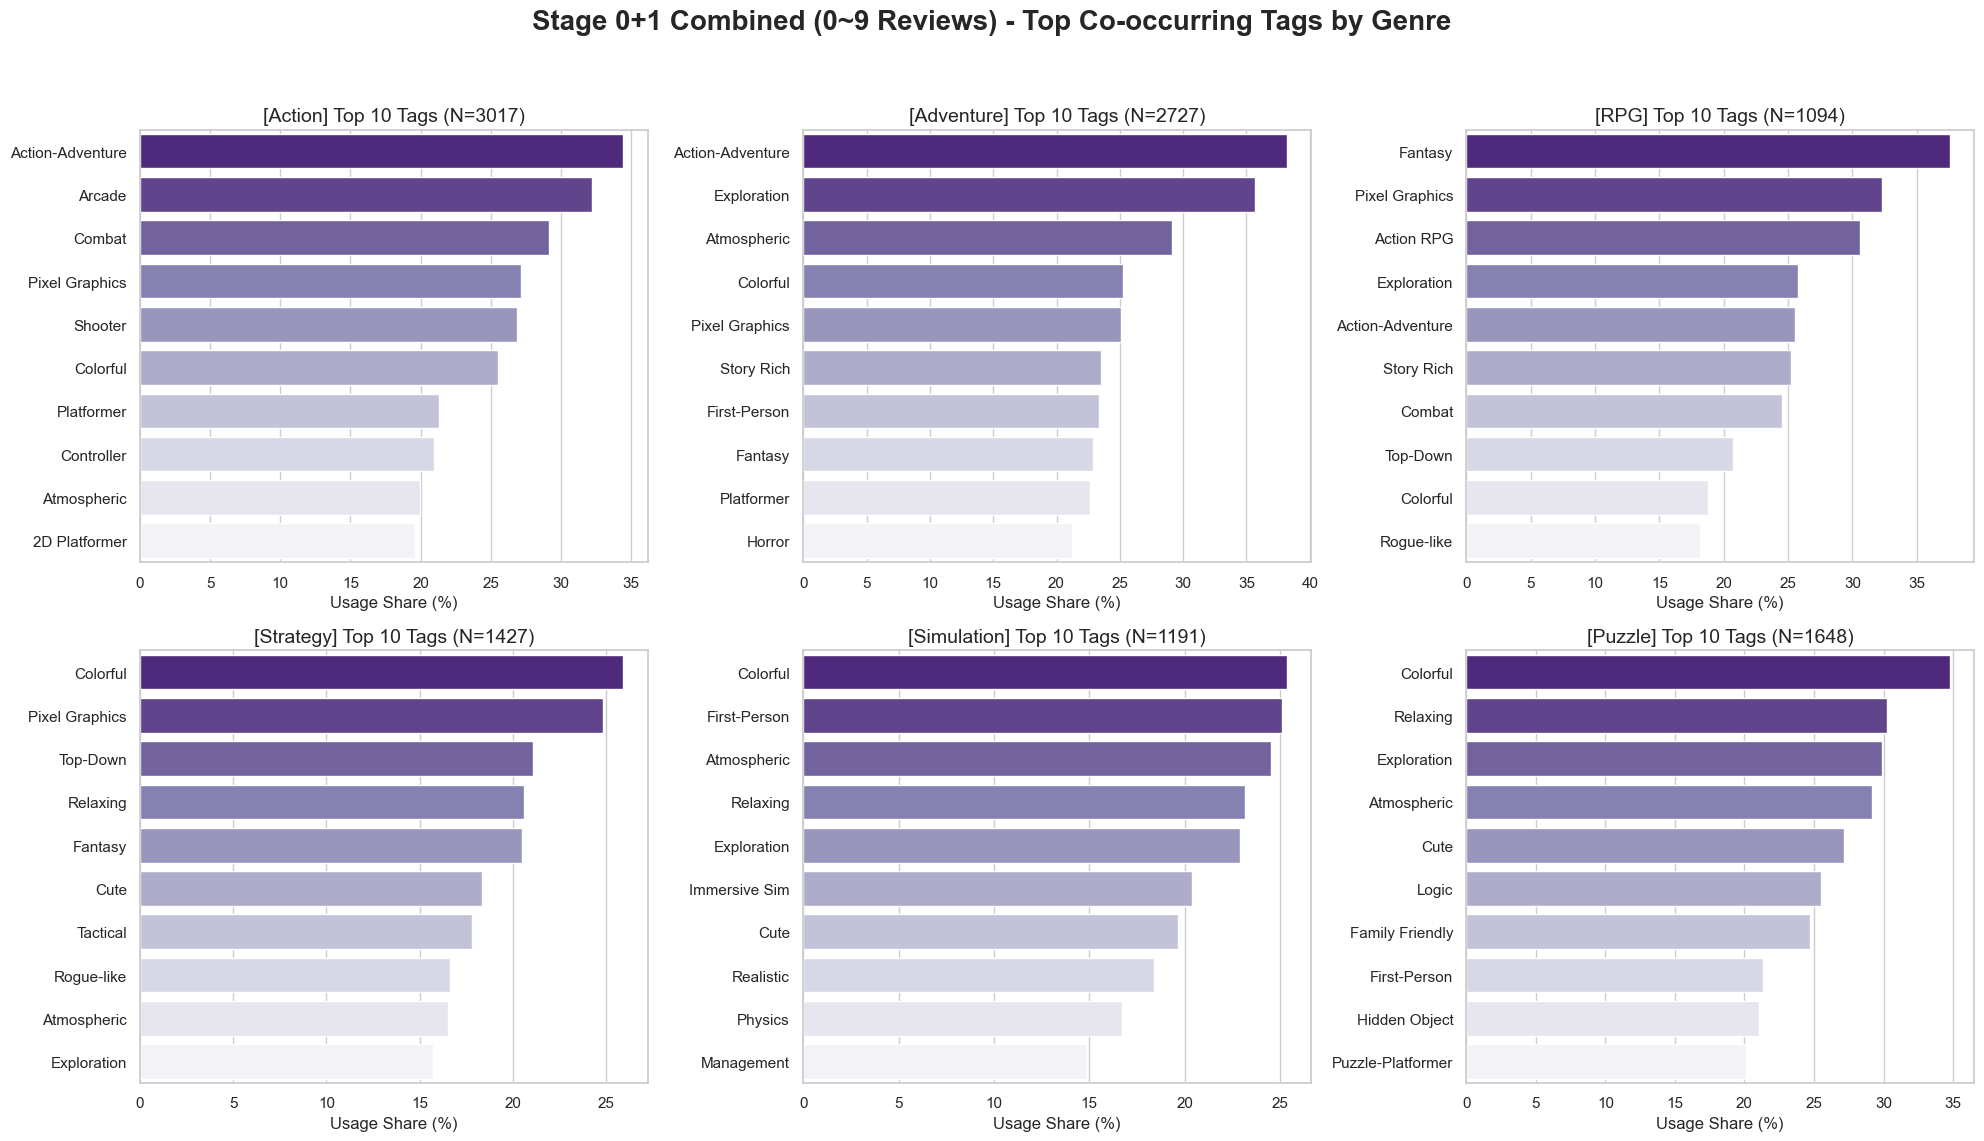


💡 [Stage 0+1 통합] 장르별 핵심 동반 태그 TOP 10 요약


,Action,Adventure,RPG,Strategy,Simulation,Puzzle
Top 1,Action-Adventure,Action-Adventure,Fantasy,Colorful,Colorful,Colorful
Top 2,Arcade,Exploration,Pixel Graphics,Pixel Graphics,First-Person,Relaxing
Top 3,Combat,Atmospheric,Action RPG,Top-Down,Atmospheric,Exploration
Top 4,Pixel Graphics,Colorful,Exploration,Relaxing,Relaxing,Atmospheric
Top 5,Shooter,Pixel Graphics,Action-Adventure,Fantasy,Exploration,Cute
Top 6,Colorful,Story Rich,Story Rich,Cute,Immersive Sim,Logic
Top 7,Platformer,First-Person,Combat,Tactical,Cute,Family Friendly
Top 8,Controller,Fantasy,Top-Down,Rogue-like,Realistic,First-Person
Top 9,Atmospheric,Platformer,Colorful,Atmospheric,Physics,Hidden Object
Top 10,2D Platformer,Horror,Rogue-like,Exploration,Management,Puzzle-Platformer


In [4]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

# 1. 시각화 기본 설정
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("="*60)
print("▶ [Stage 0+1] 리뷰 0~9개 (초기 정체 구간 통합) 게임 태그 분석 준비 중...")
print("="*60)

# 2. 데이터 로드 및 전처리
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv'
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_all = pd.concat([df_silence, df_graded], ignore_index=True)
df_all.drop_duplicates(subset=['appid'], inplace=True)

# 🚨 0단계와 1단계 통합 필터링 (리뷰 0개 이상 9개 이하)
df_target = df_all[df_all['total_reviews'] <= 9].copy()

# 3. 태그 추출 함수
def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_target['tag_list'] = df_target['tags'].apply(extract_tags)

# 4. 분석 설정
target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Puzzle']
# 공통/범용 태그 제외 (특징적인 태그만 추출하기 위함)
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access'] + target_genres

genre_top_tags = {}

# 2x3 시각화 그리드 설정
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
fig.suptitle("Stage 0+1 Combined (0~9 Reviews) - Top Co-occurring Tags by Genre", fontsize=20, fontweight='bold')

for i, genre in enumerate(target_genres):
    # 해당 장르 태그를 보유한 게임 필터링
    genre_df = df_target[df_target['tag_list'].apply(lambda x: genre in x)]
    total_genre_games = len(genre_df)
    
    if total_genre_games == 0:
        continue
        
    # 해당 장르 게임들이 가진 '다른' 특징적 태그 수집
    all_tags_in_genre = []
    for tags in genre_df['tag_list']:
        filtered_tags = [t for t in tags if t not in common_tags]
        all_tags_in_genre.extend(filtered_tags)
        
    # 태그 빈도 계산 및 비율(%) 변환
    tag_counts = Counter(all_tags_in_genre)
    top10_tags = pd.Series({tag: (count / total_genre_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
    genre_top_tags[genre] = top10_tags
    
    # 시각화 (가로 막대 그래프)
    plot_df = top10_tags.reset_index()
    plot_df.columns = ['Tag', 'Share(%)']
    
    # 이전 단계들과 구분되도록 보라색 계열(Purples_r) 사용
    sns.barplot(data=plot_df, x='Share(%)', y='Tag', ax=axes[i], palette='Purples_r')
    axes[i].set_title(f"[{genre}] Top 10 Tags (N={total_genre_games})", fontsize=14)
    axes[i].set_xlabel("Usage Share (%)")
    axes[i].set_ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 5. 결과 표 출력
print("\n💡 [Stage 0+1 통합] 장르별 핵심 동반 태그 TOP 10 요약")
summary_df = pd.DataFrame({genre: tags.index.tolist() for genre, tags in genre_top_tags.items()})
summary_df.index = [f"Top {i+1}" for i in range(10)]
display(summary_df)